In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# Interpolation convergence

> **Reproducibility.** The numerical experiments are implemented in `Interpolation_Convergence.py`. Running that script generates the static tables `pi1_pi0_results.csv` and `pid_results.csv`. This notebook does not recompute the meshes or projections; it reads those tables and is intended for explanation, visualization, and interpretation of the convergence results.


We present a numerical experiment designed to verify that the **ngsbem** implementation reproduces the theoretically predicted convergence rates of the interpolation operators associated with the trace spaces arising in boundary element discretizations. Specifically, we consider the operators

* $\Pi^1$, mapping traces in $H^{1/2}(\Gamma)$ to the boundary finite element space of `H1`,

* $\Pi^d$, mapping traces in $H^{-1/2}(\operatorname{div}_\Gamma,\Gamma)$ to the boundary finite element space `HDivSurface`, and

* $\Pi^0$, mapping traces in $H^{-1/2}(\Gamma)$ to the boundary finite element space `L2Surface`.

We study the $h$-version for a fixed polynomial order $p$. Let $\Gamma$ denote the exact geometry and let $\Gamma_h$ denote its discrete approximation. Starting from an initial mesh, we consider a sequence of uniform $h$-refinements, where the characteristic mesh size is halved at each refinement step, i.e.,

$$
h_{\mathrm{fine}} = \frac{1}{2} h_{\mathrm{coarse}}.
$$

For each trace space, we prescribe a smooth analytical density $u_{\mathrm{exa}}$ on the exact geometry $\Gamma$. In order to distinguish the approximation properties of the interpolation operator from the additional error introduced by the approximation of the geometry, we consider two related error measures.

## Interpolation error on the discrete geometry

Let $\widetilde{u}$ be a smooth extension of the analytical density $u_{\mathrm{exa}}$ to a neighborhood of $\Gamma$. Its restriction to the discrete geometry is denoted by

$$
u_h := \widetilde{u}|_{\Gamma_h}.
$$

The corresponding interpolation error is measured entirely on the discrete geometry $\Gamma_h$ and is defined by

$$
\mathrm{err}^{\mathrm{int}}_{p,h,*}
=
\frac{
\left\|
u_h-\Pi_h^* u_h
\right\|_{L^2(\Gamma_h)}
}{
\left\|
u_h
\right\|_{L^2(\Gamma_h)}
},
\qquad *\in\{1,d,0\}.
$$

This error isolates the approximation introduced by the finite element interpolation or projection on the given discrete geometry. In particular, both $u_h$ and $\Pi_h^*u_h$ are functions on $\Gamma_h$, such that no explicit comparison between the exact and discrete geometries enters this error measure.

## Combined interpolation and geometry error

To additionally account for the approximation of the exact geometry $\Gamma$ by $\Gamma_h$, we introduce a mapping

$$
p_h : \Gamma_h \rightarrow \Gamma.
$$

For the unit sphere, the natural choice is the radial projection

$$
p_h(\mathbf{x})
=
\frac{\mathbf{x}}{\|\mathbf{x}\|},
\qquad
\mathbf{x}\in\Gamma_h.
$$

The analytical density on $\Gamma$ can therefore be pulled back to the discrete geometry according to

$$
u_{\mathrm{exa}}^{\,p}(\mathbf{x})
=
u_{\mathrm{exa}}\!\left(p_h(\mathbf{x})\right),
\qquad
\mathbf{x}\in\Gamma_h.
$$

We then define the combined error by

$$
\mathrm{err}^{\mathrm{tot}}_{p,h,*}
=
\frac{
\left\|
u_{\mathrm{exa}}^{\,p}
-
\Pi_h^* u_h
\right\|_{L^2(\Gamma_h)}
}{
\left\|
u_{\mathrm{exa}}^{\,p}
\right\|_{L^2(\Gamma_h)}
},
\qquad *\in\{1,d,0\}.
$$

In contrast to $\mathrm{err}^{\mathrm{int}}_{p,h,*}$, this quantity contains two superimposed discretization effects: the approximation of the density by the finite element space and the discrepancy between the exact geometry $\Gamma$ and its discrete approximation $\Gamma_h$.

For the unit sphere, the latter can additionally be monitored independently by the relative radial geometry error

$$
\mathrm{err}^{\mathrm{geo}}_h
=
\left(
\frac{1}{|\Gamma|}
\int_{\Gamma_h}
\left(
\|\mathbf{x}\|-1
\right)^2
\,\mathrm{d}s_h
\right)^{1/2},
$$

where

$$
|\Gamma|=4\pi.
$$

Consequently, the three quantities

$$
\mathrm{err}^{\mathrm{geo}}_h,
\qquad
\mathrm{err}^{\mathrm{int}}_{p,h,*},
\qquad
\mathrm{err}^{\mathrm{tot}}_{p,h,*}
$$

allow us to distinguish the convergence of the geometry approximation, the finite element interpolation or projection on $\Gamma_h$, and their combined effect.

## Observed convergence rates

For each of these error measures, the observed convergence order is determined from two consecutive refinement levels. Assuming an asymptotic error behavior of the form

$$
\mathrm{err}_{p,h}
\sim
C h^\alpha,
$$

the observed convergence order is approximated by

$$
\alpha_h
=
\frac{
\log\left(\mathrm{err}_{p,h_{\mathrm{coarse}}}\right)
-
\log\left(\mathrm{err}_{p,h_{\mathrm{fine}}}\right)
}{
\log\left(h_{\mathrm{coarse}}\right)
-
\log\left(h_{\mathrm{fine}}\right)
}.
$$

Since uniform refinement yields

$$
h_{\mathrm{fine}}
=
\frac{1}{2}h_{\mathrm{coarse}},
$$

this simplifies to

$$
\alpha_h
=
\frac{
\log\left(\mathrm{err}_{p,h}\right)
-
\log\left(\mathrm{err}_{p,h/2}\right)
}{
\log 2
}.
$$

Thus, for an asymptotic convergence rate of order $\alpha$, we expect

$$
\alpha_h \rightarrow \alpha
$$

under uniform mesh refinement. We evaluate this convergence behavior separately for the interpolation error $\mathrm{err}^{\mathrm{int}}_{p,h,*}$ and the combined interpolation and geometry error $\mathrm{err}^{\mathrm{tot}}_{p,h,*}$.


## Laplace: $\Pi^0$ and $\Pi^1$ 

- Geometry is the unit sphere


$$ \Gamma = S_1 = \{ (x,y,z) \in \mathbb R^3: \; x^2 + y^2 + z^2 = 1\} \subset \mathbb R^3$$

- exact density is


$$ u: S_1 \mapsto \mathbb R, (x_s,y_s,z_s)\mapsto (x_s^2 + y_s^2 + z_s)\cdot(x_s - x_s^2)\cdot (y_s - y_s^2) $$

In [2]:
# Static convergence tables generated by Interpolation_Convergence.py
pi1_pi0_csv = Path("results_ref/pi1_pi0_results_ref.csv")
pid_csv = Path("results_ref/pid_results_ref.csv")


In [3]:
pi1_pi0_table = pd.read_csv(pi1_pi0_csv)
pi1_pi0_table


,p,level,h,N,ndof_Pi1,ndof_Pi0,err_geo,CF_geo,alpha_geo,err_geo_density,...,alpha_int_1,err_tot_1,CF_tot_1,alpha_tot_1,err_int_0,CF_int_0,alpha_int_0,err_tot_0,CF_tot_0,alpha_tot_0
0,1,0,0.50000,112,58,112,3.258860e-02,NaN,NaN,1.560755e-01,...,NaN,1.740779e-01,NaN,NaN,3.099302e-01,NaN,NaN,3.370722e-01,NaN,NaN
1,1,1,0.25000,448,226,448,8.556113e-03,3.808809,1.929340,4.235490e-02,...,2.036665,4.695840e-02,3.707065,1.890277,1.541347e-01,2.010774,1.007751,1.587734e-01,2.122976,1.086088
2,1,2,0.12500,1792,898,1792,2.165597e-03,3.950926,1.982191,1.081509e-02,...,2.010197,1.196850e-02,3.923500,1.972141,7.694740e-02,2.003118,1.002248,7.757665e-02,2.046665,1.033275
3,1,3,0.06250,7168,3586,7168,5.430758e-04,3.987651,1.995539,2.718227e-03,...,2.002563,3.006766e-03,3.980523,1.992958,3.845783e-02,2.000825,1.000595,3.853814e-02,2.012984,1.009336
4,1,4,0.03125,28672,14338,28672,1.358740e-04,3.996908,1.998884,6.804651e-04,...,2.000642,7.526117e-04,3.995109,1.998235,1.922691e-02,2.000209,1.000151,1.923700e-02,2.003335,1.002403
5,2,0,0.50000,112,226,336,6.840441e-04,NaN,NaN,3.833077e-03,...,NaN,1.640738e-02,NaN,NaN,8.482298e-02,NaN,NaN,8.508724e-02,NaN,NaN
6,2,1,0.25000,448,898,1344,4.435947e-05,15.420473,3.946775,2.479347e-04,...,2.908106,2.060686e-03,7.962097,2.993148,2.171483e-02,3.906224,1.965775,2.174144e-02,3.913597,1.968495
7,2,2,0.12500,1792,3586,5376,2.797452e-06,15.857099,3.987057,1.562230e-05,...,2.974713,2.578117e-04,7.992988,2.998735,5.461913e-03,3.975681,1.991202,5.463755e-03,3.979213,1.992483
8,2,3,0.06250,7168,14338,21504,1.752304e-07,15.964417,3.996788,9.783488e-07,...,2.993746,3.222739e-05,7.999769,2.999958,1.367622e-03,3.993731,1.997737,1.367740e-03,3.994733,1.998099
9,2,4,0.03125,28672,57346,86016,1.095799e-08,15.991113,3.999198,6.117727e-08,...,2.998441,4.028403e-06,8.000042,3.000008,3.420404e-04,3.998421,1.999430,3.420478e-04,3.998679,1.999524


In [4]:
# Last refinement level for each polynomial order
pi1_pi0_table.groupby("p").tail(1)[[
    "p", "h", "err_geo", "alpha_geo",
    "err_geo_density", "alpha_geo_density",
    "err_int_1", "alpha_int_1", "err_tot_1", "alpha_tot_1",
    "err_int_0", "alpha_int_0", "err_tot_0", "alpha_tot_0",
]]


,p,h,err_geo,alpha_geo,err_geo_density,alpha_geo_density,err_int_1,alpha_int_1,err_tot_1,alpha_tot_1,err_int_0,alpha_int_0,err_tot_0,alpha_tot_0
4,1,0.03125,1.358740e-04,1.998884,6.804651e-04,1.998073,4.697291e-04,2.000642,7.526117e-04,1.998235,1.922691e-02,1.000151,1.923700e-02,1.002403
9,2,0.03125,1.095799e-08,3.999198,6.117727e-08,3.999281,4.026941e-06,2.998441,4.028403e-06,3.000008,3.420404e-04,1.999430,3.420478e-04,1.999524
14,3,0.03125,3.074393e-09,3.998731,1.775577e-08,3.998797,4.362384e-08,3.999252,5.077276e-08,3.998863,2.469390e-06,2.998781,2.469485e-06,2.998947
19,4,0.03125,4.588891e-13,5.998960,2.943213e-12,5.998963,4.165992e-10,4.998582,4.166411e-10,4.999017,2.638433e-08,3.999229,2.638522e-08,3.999375


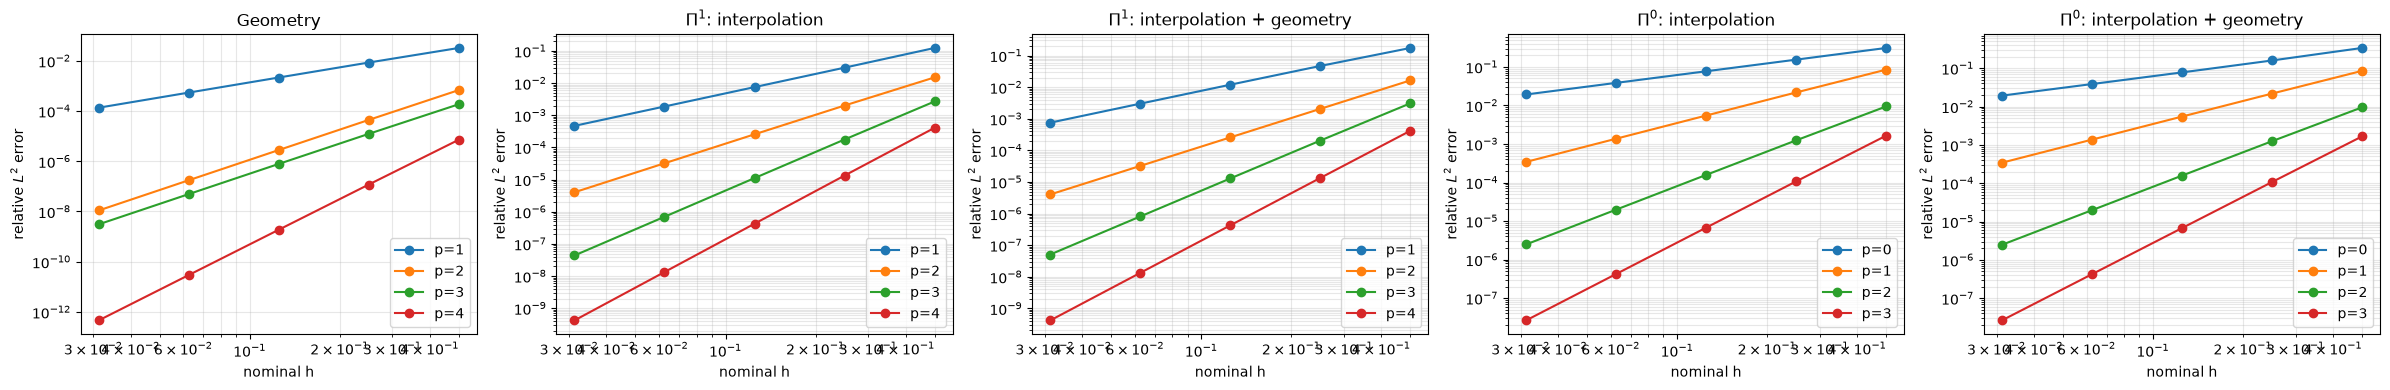

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))

for p, values in pi1_pi0_table.groupby("p"):
    axes[0].loglog(values["h"], values["err_geo"], "o-", label=f"p={p}")
    axes[1].loglog(values["h"], values["err_int_1"], "o-", label=f"p={p}")
    axes[2].loglog(values["h"], values["err_tot_1"], "o-", label=f"p={p}")
    axes[3].loglog(values["h"], values["err_int_0"], "o-", label=f"p={p-1}")
    axes[4].loglog(values["h"], values["err_tot_0"], "o-", label=f"p={p-1}")

titles = [
    r"Geometry",
    r"$\Pi^1$: interpolation",
    r"$\Pi^1$: interpolation + geometry",
    r"$\Pi^0$: interpolation",
    r"$\Pi^0$: interpolation + geometry",
]

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("nominal h")
    ax.set_ylabel("relative $L^2$ error")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()


### Interpretation

The columns `err_int_1` and `err_int_0` measure the interpolation/projection error entirely on the discrete surface $\Gamma_h$. They therefore isolate the finite element approximation on the given geometry. The columns `err_tot_1` and `err_tot_0` compare the discrete projections with the exact analytical density pulled back from the unit sphere and thus contain both interpolation and geometry effects. The additional quantity `err_geo_density` measures the discrepancy between the smooth extension evaluated on $\Gamma_h$ and the pulled-back exact density.

For the asymptotic regime, the observed orders `alpha_*` should approach the theoretically predicted rates. Comparing interpolation-only and total errors also shows whether the geometry approximation limits the observed convergence.


## Maxwell: $\Pi^d$


- Geometry is the unit sphere


$$ \Gamma = S_1 = \{ (x,y,z) \in \mathbb R^3: \; x^2 + y^2 + z^2 = 1\} \subset \mathbb R^3$$

- exact density in $H^{-\frac12}(\mathrm{div}_\Gamma, \Gamma)$ is


$$ m: S_1 \mapsto \mathbb R^3, (x_s,y_s,z_s)\mapsto - \vec n \times \vec e_x e^{-i \, \kappa \, z}$$

where $\vec n$ denotes the unit normal on $S_1$.

In [6]:
pid_table = pd.read_csv(pid_csv)
pid_table


,p,level,h,N,ndof,err_int_d,CF_int_d,alpha_int_d,err_geo_d,CF_geo_d,alpha_geo_d,err_tot_d,CF_tot_d,alpha_tot_d
0,1,0,0.50000,112,168,4.024022e-01,NaN,NaN,1.858117e-01,NaN,NaN,4.453866e-01,NaN,NaN
1,1,1,0.25000,448,672,2.103792e-01,1.912748,0.935647,8.079270e-02,2.299858,1.201545,2.258110e-01,1.972386,0.979942
2,1,2,0.12500,1792,2688,1.064162e-01,1.976947,0.983274,3.858277e-02,2.094010,1.066268,1.132576e-01,1.993782,0.995508
3,1,3,0.06250,7168,10752,5.336411e-02,1.994153,0.995776,1.905303e-02,2.025020,1.017936,5.667152e-02,1.998493,0.998912
4,1,4,0.03125,28672,43008,2.670164e-02,1.998533,0.998941,9.496335e-03,2.006357,1.004578,2.834106e-02,1.999626,0.999730
5,2,0,0.50000,112,336,2.106124e-01,NaN,NaN,6.998092e-03,NaN,NaN,2.114235e-01,NaN,NaN
6,2,1,0.25000,448,1344,5.699625e-02,3.695197,1.885651,8.759492e-04,7.989153,2.998043,5.705392e-02,3.705679,1.889738
7,2,2,0.12500,1792,5376,1.454012e-02,3.919930,1.970828,1.095149e-04,7.998450,2.999720,1.454384e-02,3.922891,1.971917
8,2,3,0.06250,7168,21504,3.653547e-03,3.979727,1.992670,1.368993e-05,7.999667,2.999940,3.653781e-03,3.980491,1.992946
9,2,4,0.03125,28672,86016,9.145491e-04,3.994916,1.998165,1.711258e-06,7.999920,2.999986,9.145638e-04,3.995108,1.998235


In [7]:
# Last refinement level for each polynomial order
pid_table.groupby("p").tail(1)[[
    "p", "h", "ndof",
    "err_int_d", "alpha_int_d",
    "err_geo_d", "alpha_geo_d",
    "err_tot_d", "alpha_tot_d",
]]


,p,h,ndof,err_int_d,alpha_int_d,err_geo_d,alpha_geo_d,err_tot_d,alpha_tot_d
4,1,0.03125,43008,2.670164e-02,0.998941,9.496335e-03,1.004578,2.834106e-02,0.999730
9,2,0.03125,86016,9.145491e-04,1.998165,1.711258e-06,2.999986,9.145638e-04,1.998235
14,3,0.03125,215040,1.126548e-05,2.998062,9.775713e-07,2.999127,1.142448e-05,2.997995
19,4,0.03125,401408,1.428421e-07,3.997835,1.995197e-10,4.999178,1.428440e-07,3.997893


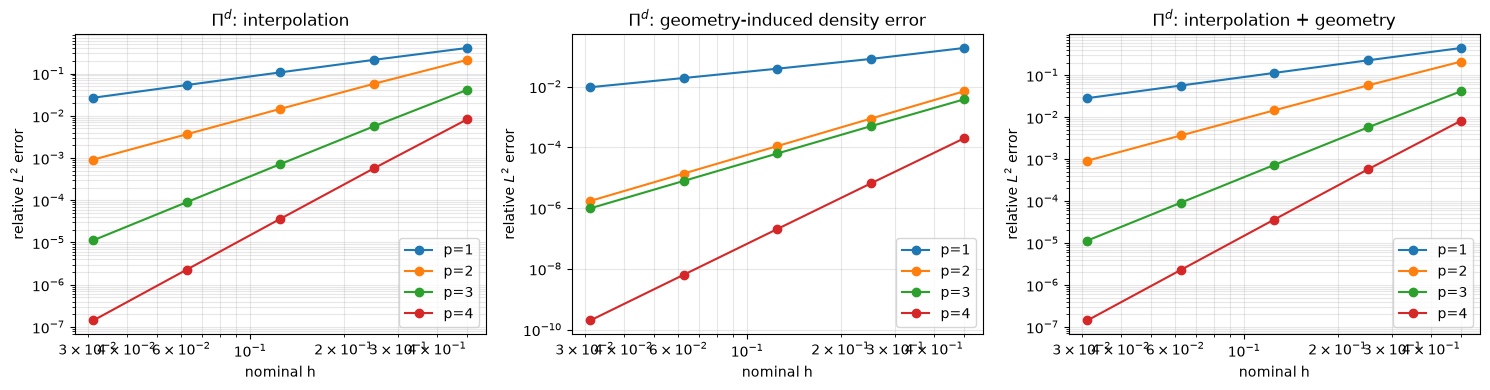

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for p, values in pid_table.groupby("p"):
    axes[0].loglog(values["h"], values["err_int_d"], "o-", label=f"p={p}")
    axes[1].loglog(values["h"], values["err_geo_d"], "o-", label=f"p={p}")
    axes[2].loglog(values["h"], values["err_tot_d"], "o-", label=f"p={p}")

titles = [
    r"$\Pi^d$: interpolation",
    r"$\Pi^d$: geometry-induced density error",
    r"$\Pi^d$: interpolation + geometry",
]

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("nominal h")
    ax.set_ylabel("relative $L^2$ error")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()


### Interpretation

For $\Pi^d$, `err_int_d` compares the PBI result with the tangential density defined intrinsically on $\Gamma_h$. `err_geo_d` measures the discrepancy between this density and the analytical density pulled back from the exact sphere. `err_tot_d` combines both effects by comparing the discrete projection directly with the pulled-back analytical density.

The separation is particularly useful for the tangential trace because the normal field, and hence the tangential density, changes with the geometry approximation. The observed orders `alpha_int_d`, `alpha_geo_d`, and `alpha_tot_d` make it possible to identify which contribution controls the asymptotic rate.
